<a href="https://colab.research.google.com/github/MKU-irul/datasharing/blob/master/pythonRefreshment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Part":["IC17","C551","D551","L551"],
    "Temp":[65,77,105,89]
})

print(df)
print("")

print("Temp Max: ", df["Temp"].max())
print("Temp MIn: ", df["Temp"].min())
print("Temp Avg: ", df["Temp"].mean())
print("Temp Sum: ", df["Temp"].sum())
print("Item Count: ", df["Temp"].count())

   Part  Temp
0  IC17    65
1  C551    77
2  D551   105
3  L551    89

Temp Max:  105
Temp MIn:  65
Temp Avg:  84.0
Temp Sum:  336
Item Count:  4


In [ ]:
from google.colab import files
uploaded = files.upload()



Saving Limit.xlsx to Limit.xlsx
Saving Sample.xlsx to Sample.xlsx


Start Analysis Time (sec): 7000
End Analysis Time (sec): 9000

Lifetime Mode
1 = Finished Product (FAX)
2 = Finished Product (Non-FAX)
3 = Single Unit
Select Lifetime Mode : 3
Rows : 23991
Cols : 24


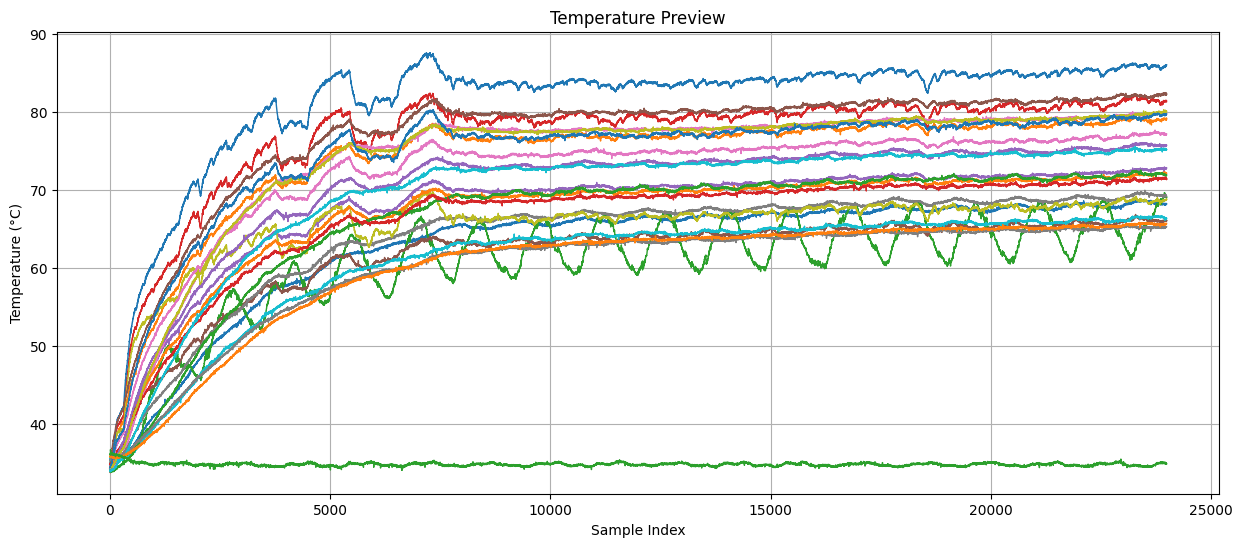

Analysis Start Row : 14003
Analysis End Row : 18003
FOUND ROOM TEMP = 36.35
            Part   Part code     Maker                Category  \
0            C12  909xbcxbcx      Fuji               Capacitor   
1            R31       fsr33  Pansonic                Resistor   
2            R31       bdf45  Pansonic                Resistor   
3     DB1 (lead)      hyjy81      ROHM            Bridge Diode   
4     D51 (main)       fsr34      Fuji                   Diode   
5            R39      hyjy79      ROHM                Resistor   
6     DB1 (main)       bdf49  Pansonic            Bridge Diode   
7      T1 (core)  909xbcxbcx      Fuji           Transformator   
8            C11  909xbcxbcx      Fuji  Electrolysis Capacitor   
9            TH1       bdf48  Pansonic              Thermistor   
10           C13      hyjy82      ROHM               Capacitor   
11    D51 (lead)  fsdfwe3237      ROHM                   Diode   
12            D5       bdf47  Pansonic                   Diode   


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl.styles import PatternFill, Font
from openpyxl.drawing.image import Image
from datetime import datetime
import matplotlib.pyplot as plt

# =========================
# USER SETTING
# =========================
PART_ROW = 2
DATA_START = 3

ROOM_KEYWORDS = [
    "room",
    "ambient"
]


# =========================
# READ MEASUREMENT FILE
# =========================
def read_file(file_name):

    raw = pd.read_excel(
        file_name,
        sheet_name=0,
        header=None
    )

    print("Rows :", raw.shape[0])
    print("Cols :", raw.shape[1])

    return raw

# =========================
# PREVIEW GRAPH
# =========================
def preview_graph(raw):

    plt.figure(
        figsize=(15, 6)
    )

    for col in range(1, len(raw.columns)):

        part_name = raw.iloc[PART_ROW, col]

        if pd.isna(part_name):
            continue

        y = pd.to_numeric(
            raw.iloc[DATA_START:, col],
            errors="coerce"
        )

        plt.plot(
            y.values,
            linewidth=1
        )

    plt.title(
        "Temperature Preview"
    )

    plt.xlabel(
        "Sample Index"
    )

    plt.ylabel(
        "Temperature (°C)"
    )

    plt.grid(True)

    plt.show()


# =========================
# READ LIMIT DATABASE
# =========================
def read_limit(limit_file):

    limit_df = pd.read_excel(limit_file)
    # Strip whitespace from column names to ensure exact matches
    limit_df.columns = limit_df.columns.str.strip()
    # Strip whitespace from 'Part' column data for robust merging
    limit_df['Part'] = limit_df['Part'].str.strip()

    # Robustly handle spelling typo 'Categogry' in Limit.xlsx
    limit_df = limit_df.rename(columns={"Categogry": "Category"})

    return limit_df


# =========================
# FIND START ROW
# =========================
def find_start_row(raw, start_time_sec):

    time_col = raw.iloc[DATA_START:, 0]

    time_sec = []

    for t_str in time_col:

        t_lower = str(t_str).strip().lower()
        value = 0.0

        if "ms" in t_lower:
            # Handle milliseconds: e.g., '100ms'
            numeric_part = t_lower.replace("ms", "")
            try:
                value = float(numeric_part) / 1000
            except ValueError:
                value = 0.0
        else:
            # Handle h, m, s combinations
            hours = 0.0
            minutes = 0.0
            seconds = 0.0

            current_str = t_lower

            # Extract hours
            if 'h' in current_str:
                parts_h = current_str.split('h')
                try:
                    hours = float(parts_h[0]) if parts_h[0] else 0.0
                except ValueError:
                    hours = 0.0
                current_str = parts_h[1] # Remaining part after hours

            # Extract minutes
            if 'm' in current_str:
                parts_m = current_str.split('m')
                try:
                    minutes = float(parts_m[0]) if parts_m[0] else 0.0
                except ValueError:
                    minutes = 0.0
                current_str = parts_m[1] # Remaining part after minutes

            # Extract seconds
            if 's' in current_str:
                parts_s = current_str.split('s')
                try:
                    seconds = float(parts_s[0]) if parts_s[0] else 0.0
                except ValueError:
                    seconds = 0.0
                current_str = parts_s[1] # Remaining part after seconds

            # If any part remains, it should be a pure float (e.g., if input was just '123.45' or leftover seconds without 's')
            if current_str:
                try:
                    seconds += float(current_str) # Add any remaining numeric part as seconds
                except ValueError:
                    seconds = 0.0

            value = hours * 3600 + minutes * 60 + seconds

        time_sec.append(value)

    time_sec = pd.Series(
        time_sec,
        index=time_col.index
    )

    matching_series = time_sec[
        time_sec >= start_time_sec
    ]

    if not matching_series.empty:
        idx = matching_series.index[0]
    else:
        # Fallback to the very last index in the data if the target time exceeds max range
        idx = time_sec.index[-1]

    return idx


# =========================
# MAKE SUMMARY
# =========================
def make_summary(raw, limit_df, start_row, end_row):

    hasil = []

    # Ensure part names from raw data are also stripped for accurate lookup
    limit_dict = dict(
        zip(
            limit_df["Part"],
            limit_df["Limit"]
        )
    )

    # Find room temperature once
    room_temp = None

    for col_idx in range(1, len(raw.columns)):
        current_part_name = str(
            raw.iloc[PART_ROW, col_idx]
        ).strip().lower()

        if (
            "room" in current_part_name
            or
            "ambient" in current_part_name
        ):
            # Extract temp data for the room part
            room_data = pd.to_numeric(raw.iloc[DATA_START:, col_idx], errors="coerce")
            room_temp = room_data.max()
            print(
                "FOUND ROOM TEMP =",
                room_temp
            )
            break # Assuming only one room temperature source is needed

    if room_temp is None:
        # Default room_temp if not found to avoid NameError, or raise an exception
        print("Warning: No room temperature part found in data. Using 25.0 as default room_temp.")
        room_temp = 25.0

    for col in range(1, len(raw.columns)):

        part_name = raw.iloc[PART_ROW, col]

        if pd.isna(part_name):
            continue

        part_name = str(part_name).strip() # Strip whitespace from part_name from raw data
        part_name_lower = part_name.lower()

        # Room Temperature (check if part name contains any room keyword)
        if any(keyword in part_name_lower for keyword in ROOM_KEYWORDS):

            temp_data = pd.to_numeric(
                raw.iloc[DATA_START:, col],
                errors="coerce"
            )

        # Normal Part
        else:

            temp_data = pd.to_numeric(
                raw.iloc[start_row:end_row, col],
                errors="coerce"
            )

        max_temp = temp_data.max()

        converted_temp = round(
            max_temp - room_temp + 40,
            2
        )

        avg_temp = temp_data.mean()

        std_temp = temp_data.std()

        limit = limit_dict.get(part_name)

        if limit is None:
            status = "NO LIMIT"
        else:
            status = "NG" if converted_temp > limit else "OK"

        hasil.append([
            part_name,
            round(avg_temp, 2),
            round(max_temp, 2),
            round(converted_temp, 2),
            round(std_temp, 3),
            limit,
            status
        ])

    result = pd.DataFrame(
        hasil,
        columns=[
            "Part",
            "Avg Temp",
            "Max Temp",
            "Converted Temp",
            "Std Dev",
            "Limit",
            "Status"
        ]
    )

    result = result.merge(
        limit_df,
        on="Part",
        how="left",
        suffixes=('', '_from_limit_df') # Preserve 'Limit' from 'result', rename 'Limit' from 'limit_df'
    )

    # Check if 'Category' exists in the merged result dataframe. If not, add an empty placeholder
    if "Category" not in result.columns:
        result["Category"] = ""

    # Ensure key columns for lifetime calculation are preserved if they exist
    cols_to_select = [
        "Part",
        "Part code",
        "Maker",
        "Category",
        "Taping Point",
        "Avg Temp",
        "Max Temp",
        "Converted Temp",
        "Std Dev",
        "Limit",
        "Status"
    ]
    if "Rated Temp" in result.columns:
        cols_to_select.append("Rated Temp")
    if "Rated Life" in result.columns:
        cols_to_select.append("Rated Life")

    result = result[cols_to_select]

    return result, room_temp



# =========================
# GENERATE GRAPH
# =========================
def generate_graph(raw, start_row):
    plt.figure(figsize=(18, 8))
    time_data = pd.to_numeric(
        raw.iloc[DATA_START:, 0],
        errors="coerce"
    )

    for col in range(1, len(raw.columns)):
        part_name = str(raw.iloc[PART_ROW, col]).strip()
        if part_name == "" or part_name == "nan":
            continue

        temp_data = pd.to_numeric(
            raw.iloc[DATA_START:, col],
            errors="coerce"
)
        plt.plot(time_data, temp_data, linewidth=1, label=part_name)

    plt.axvline(
        x=time_data.loc[start_row],
        linestyle="--",
        linewidth=2
    )
    plt.axvline(
        x=end_time_sec,
        linestyle="--",
        linewidth=2
    )
    plt.axvspan(
        start_time_sec,
        end_time_sec,
        alpha=0.2
    )
    plt.title("Temperature Rise Measurement")
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")
    plt.grid(True)
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=7
    )
    plt.savefig("temperature_graph.png", bbox_inches="tight")
    plt.close()

# =========================
# CALCULATE LIFETIME
# =========================
def calculate_lifetime(
    result,
    room_temp,
    lifetime_mode
):

    cap_df = result[
        result["Category"]
        .str.contains(
            "Electro",
            case=False,
            na=False
        )
    ].copy()

    if len(cap_df) == 0:

        return pd.DataFrame()

    cap_df["Life Temp"] = (
        cap_df["Max Temp"]
        - room_temp
        + 35
    )

    # Single Unit
    if lifetime_mode == 3:

        cap_df["Estimated Life"] = (
            cap_df["Rated Life"]
            *
            (
                2 **
                (
                    (
                        cap_df["Rated Temp"]
                        -
                        cap_df["Life Temp"]
                    ) / 10
                )
            )
        ).round().astype(int)

        life_standard = 20000

    else:

        # sementara dummy dulu
        cap_df["Estimated Life"] = 0

        life_standard = 50000

    cap_df["Standard"] = life_standard

    cap_df["Judgment"] = np.where(
        cap_df["Estimated Life"]
        >=
        life_standard,
        "PASS",
        "FAIL"
    )

    return cap_df[
        [
            "Part",
            "Part code",
            "Maker",
            "Life Temp",
            "Rated Temp",
            "Rated Life",
            "Estimated Life",
            "Standard",
            "Judgment"
        ]
    ]


# =========================
# SAVE FILE
# =========================
def save_file(result, raw, start_row, lifetime_result):

    timestamp = datetime.now().strftime(
        "%Y%m%d_%H%M%S"
    )

    output_file = (
        f"Temperature_Report_{timestamp}.xlsx"
    )

    # =========================
    # NG ONLY
    # =========================
    ng_only = result[
        result["Status"] == "NG"
    ].copy()

    # =========================
    # STATISTICS
    # =========================
    total_part = len(result)
    total_ok = len(
        result[result["Status"] == "OK"]
    )
    total_ng = len(
        result[result["Status"] == "NG"]
    )
    total_no_limit = len(
        result[result["Status"] == "NO LIMIT"]
    )

    statistics = pd.DataFrame({
        "Item": [
            "Total Part",
            "OK",
            "NG",
            "NO LIMIT"
        ],
        "Value": [
            total_part,
            total_ok,
            total_ng,
            total_no_limit
        ]
    })

    # =========================
    # SAVE EXCEL
    # =========================
    with pd.ExcelWriter(
        output_file,
        engine="openpyxl"
    ) as writer:

        # Summary
        # Drop auxiliary calculation columns if they exist before exporting summary to excel
        cols_to_export = [c for c in result.columns if c not in ["Rated Temp", "Rated Life"]]
        result[cols_to_export].to_excel(
            writer,
            sheet_name="Summary",
            index=False
        )

        # NG Only
        ng_only.to_excel(
            writer,
            sheet_name="NG Only",
            index=False
        )

        # Statistics
        statistics.to_excel(
            writer,
            sheet_name="Statistics",
            index=False
        )

        # =========================
        # FORMAT SUMMARY
        # =========================
        ws = writer.book["Summary"]

        green_fill = PatternFill(
            fill_type="solid",
            start_color="C6EFCE"
        )
        red_fill = PatternFill(
            fill_type="solid",
            start_color="FFC7CE"
        )
        yellow_fill = PatternFill(
            fill_type="solid",
            start_color="FFEB9C"
        )

        # Header Bold
        for cell in ws[1]:
            cell.font = Font(bold=True)

        # Cari kolom Status
        status_col = None
        for cell in ws[1]:
            if cell.value == "Status":
                status_col = cell.column
                break

        # Coloring Status
        if status_col:
            for row in range(2, ws.max_row + 1):
                status_cell = ws.cell(row=row, column=status_col)
                if status_cell.value == "OK":
                    status_cell.fill = green_fill
                elif status_cell.value == "NG":
                    status_cell.fill = red_fill
                elif status_cell.value == "NO LIMIT":
                    status_cell.fill = yellow_fill

        # Auto Width
        for column in ws.columns:
            max_length = 0
            col_letter = column[0].column_letter
            for cell in column:
                try:
                    if cell.value:
                        max_length = max(
                            max_length,
                            len(str(cell.value))
                        )
                except:
                    pass
            ws.column_dimensions[col_letter].width = max_length + 3

        # =========================
        # FORMAT NG ONLY
        # =========================
        ws_ng = writer.book["NG Only"]
        for cell in ws_ng[1]:
            cell.font = Font(bold=True)

        for column in ws_ng.columns:
            max_length = 0
            col_letter = column[0].column_letter
            for cell in column:
                try:
                    if cell.value:
                        max_length = max(
                            max_length,
                            len(str(cell.value))
                        )
                except:
                    pass
            ws_ng.column_dimensions[col_letter].width = max_length + 3

        # =========================
        # FORMAT STATISTICS
        # =========================
        ws_stat = writer.book["Statistics"]
        for cell in ws_stat[1]:
            cell.font = Font(bold=True)

        # =========================
        # ADD TEMPERATURE GRAPH SHEET
        # =========================
        generate_graph(raw, start_row)
        ws_graph = writer.book.create_sheet("Temperature Graph")
        img = Image("temperature_graph.png")
        ws_graph.add_image(img, "A1")

        # =========================
        # PRINT REPORT
        # =========================

        report_df = pd.DataFrame()

        report_df["No"] = range(
            1,
            len(result) + 1
        )

        report_df["Part"] = result["Category"]

        report_df["Part Name"] = result["Part"]

        report_df["Manufacturer"] = result["Maker"]

        report_df["Ta"] = result["Part code"]

        report_df["Measured Temp"] = result["Max Temp"]

        report_df["Converted Temp"] = result["Converted Temp"]

        report_df["Allowable Temp"] = result["Limit"]

        report_df["Judgment"] = result["Status"]

        report_df["Measurement Point"] = result["Taping Point"]

        report_df.to_excel(
            writer,
            sheet_name="Print Report",
            index=False
        )

        ws_report = writer.sheets["Print Report"]

        lifetime_result.to_excel(
            writer,
            sheet_name="Lifetime",
            index=False
        )

        ws_report.page_setup.paperSize = ws_report.PAPERSIZE_A4
        ws_report.page_setup.orientation = "landscape"

        ws_report.page_setup.fitToWidth = 1
        ws_report.page_setup.fitToHeight = 0

        from openpyxl.styles import Border, Side

        thin = Side(style="thin")

        border = Border(
            left=thin,
            right=thin,
            top=thin,
            bottom=thin
        )

        for row in ws_report.iter_rows():
            for cell in row:
                cell.border = border

        from openpyxl.styles import Alignment
        for cell in ws_report[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center"
            )

        for row in ws_report.iter_rows(min_row=2):
            for cell in row:
                cell.alignment = Alignment(
                    horizontal="center",
                    vertical="center"
                )

        for column in ws_report.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    max_length = max(
                        max_length,
                        len(str(cell.value))
                    )
                except:
                    pass
            ws_report.column_dimensions[column_letter].width = max_length + 3

        ws_report.column_dimensions["A"].width = 6    # No
        ws_report.column_dimensions["B"].width = 25   # Part
        ws_report.column_dimensions["C"].width = 20   # Part Name
        ws_report.column_dimensions["D"].width = 20   # Manufacturer
        ws_report.column_dimensions["E"].width = 15   # Ta
        ws_report.column_dimensions["F"].width = 15   # Measured
        ws_report.column_dimensions["G"].width = 15   # Converted
        ws_report.column_dimensions["H"].width = 15   # Allowable
        ws_report.column_dimensions["I"].width = 12   # Judgment
        ws_report.column_dimensions["J"].width = 25   # Measurement Point

    print()
    print("===============================")
    print("REPORT GENERATED")
    print(output_file)
    print("===============================")


# =========================
# MAIN
# =========================
start_time_sec = float(
    input("Start Analysis Time (sec): ")
)

end_time_sec = float(
    input("End Analysis Time (sec): ")
)
print("\nLifetime Mode")
print("1 = Finished Product (FAX)")
print("2 = Finished Product (Non-FAX)")
print("3 = Single Unit")

lifetime_mode = int(
    input("Select Lifetime Mode : ")
)
raw = read_file(
    "Sample.xlsx"
)

preview_graph(raw)

limit_df = read_limit(
    "Limit.xlsx"
)

start_row = find_start_row(
    raw,
    start_time_sec
)
end_row = find_start_row(
    raw,
    end_time_sec
)

print("Analysis Start Row :", start_row)
print("Analysis End Row :", end_row)

result, room_temp = make_summary(
    raw,
    limit_df,
    start_row,
    end_row
)

lifetime_result = calculate_lifetime(
    result,
    room_temp,
    lifetime_mode
)

print(result)

print("\n===== LIFETIME =====")
print(lifetime_result)

save_file(
    result,
    raw,
    start_row,
    lifetime_result
)